# Practical Work 3: Recurrent Neural Networks
## Part A: Time Series Forecasting | Part B: Text Generation

**Goal:** Study LSTM and GRU architectures for sequential data.

**Outline:**
- **Part A — Time Series:**
  1. Load BTC/USD daily price data
  2. Preprocess: normalize, create sliding windows
  3. Build LSTM forecasting model
  4. Train, evaluate (MAE, RMSE, R²), visualize
  5. Optional: Compare LSTM vs GRU vs Transformer

- **Part B — Text Generation:**
  1. Load text corpus (Shakespeare)
  2. Character-level tokenization
  3. Build character LSTM language model
  4. Train with perplexity tracking
  5. Generate text with temperature sampling

## Setup

In [13]:
!pip install pandas-datareader yfinance scikit-learn -q

In [14]:
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


---
# PART A: Time Series Forecasting (BTC/USD Price)
---

## A1. Load & Explore Data

Dataset: 1462 days of BTC/USD closing prices
               Close
count    1462.000000
mean    60357.575917
std     32217.537177
min     15787.284180
25%     27403.080078
50%     63193.000000
75%     88335.726562
max    124752.531250


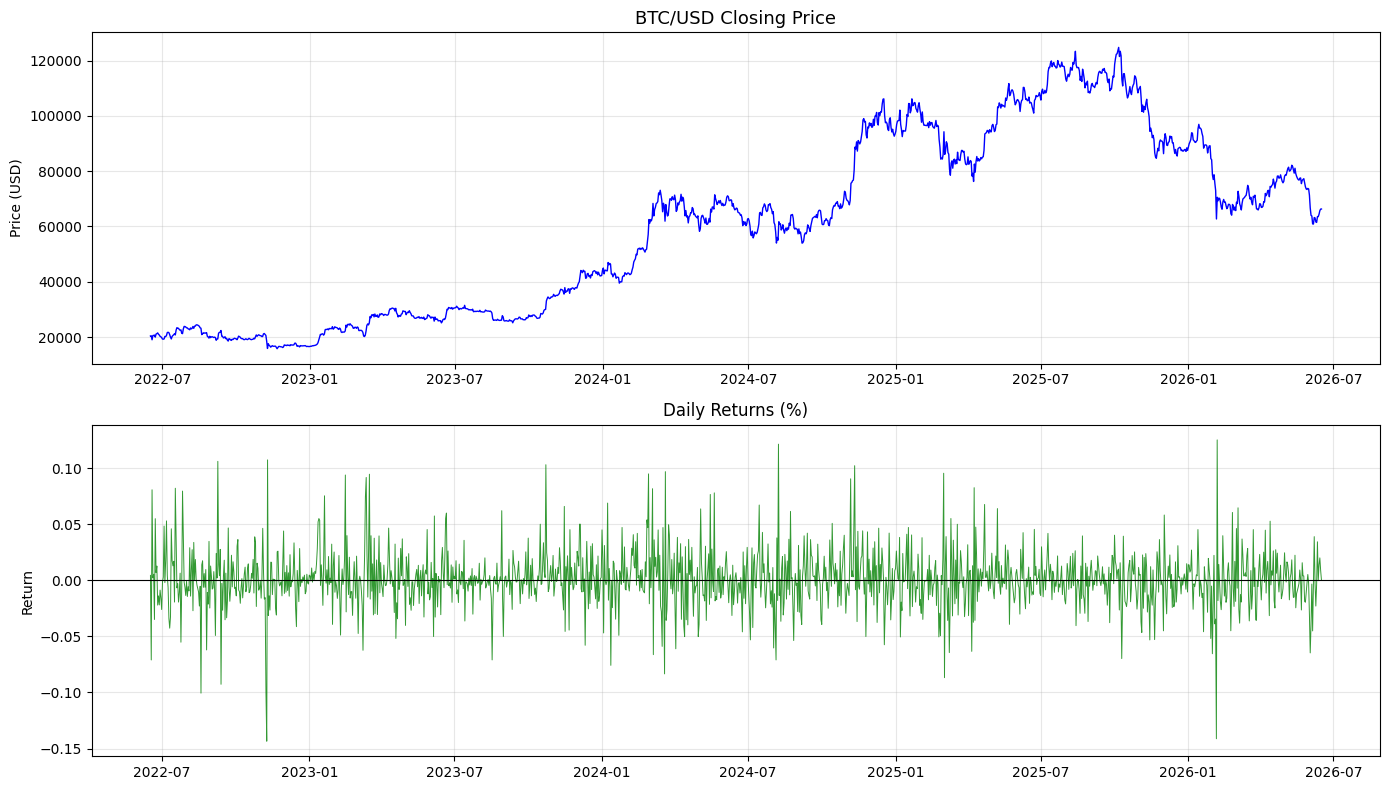

In [15]:
import yfinance as yf

# Download 4 years of daily BTC/USD closing prices
ticker = yf.Ticker('BTC-USD')
df = ticker.history(period='4y', interval='1d')
df = df[['Close']].dropna()
df.index = pd.to_datetime(df.index)
df.index = df.index.tz_localize(None)  # Remove timezone

print(f'Dataset: {len(df)} days of BTC/USD closing prices')
print(df.describe())

# Plot the full time series
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(df.index, df['Close'], 'b-', linewidth=1)
axes[0].set_title('BTC/USD Closing Price', fontsize=13)
axes[0].set_ylabel('Price (USD)')
axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Daily returns
df['returns'] = df['Close'].pct_change()
axes[1].plot(df.index, df['returns'], 'g-', linewidth=0.7, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Daily Returns (%)')
axes[1].set_ylabel('Return')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('btc_price.png', dpi=100, bbox_inches='tight')
plt.show()

## A2. Preprocessing: Normalize & Create Sliding Windows

In [16]:
# ── Normalization ──────────────────────────────────────────
prices = df['Close'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
prices_scaled = scaler.fit_transform(prices)

# ── Train/Val/Test split (chronological — no shuffling!) ───
n = len(prices_scaled)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_data = prices_scaled[:train_end]
val_data   = prices_scaled[train_end:val_end]
test_data  = prices_scaled[val_end:]

print(f'Total:  {n} samples')
print(f'Train:  {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')

# ── Sliding Window Dataset ─────────────────────────────────
WINDOW_SIZE = 60   # Use 60 days to predict the next day

def create_sequences(data, window_size):
    """Convert time series into (X, y) pairs using a sliding window."""
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size : i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data, WINDOW_SIZE)
X_val,   y_val   = create_sequences(val_data,   WINDOW_SIZE)
X_test,  y_test  = create_sequences(test_data,  WINDOW_SIZE)

# Reshape for PyTorch LSTM: (batch, seq_len, features)
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
X_val   = torch.tensor(X_val,   dtype=torch.float32).unsqueeze(-1)
y_val   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(-1)
X_test  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(-1)
y_test  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(-1)

print(f'\nX_train shape: {X_train.shape}  (batch, seq_len=60, features=1)')
print(f'y_train shape: {y_train.shape}')

# DataLoaders
from torch.utils.data import TensorDataset
BATCH = 32
train_loader_ts = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH, shuffle=True)
val_loader_ts   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=BATCH, shuffle=False)
test_loader_ts  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=BATCH, shuffle=False)

Total:  1462 samples
Train:  1023 | Val: 219 | Test: 220

X_train shape: torch.Size([963, 60, 1])  (batch, seq_len=60, features=1)
y_train shape: torch.Size([963, 1])


## A3. LSTM & GRU Model Architectures

In [17]:
class LSTMForecaster(nn.Module):
    """
    2-layer stacked LSTM for time series forecasting.
    Input:  (batch, seq_len, 1)
    Output: (batch, 1)  — next step prediction
    """
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        # lstm_out: (batch, seq_len, hidden_size)
        lstm_out, _ = self.lstm(x)
        # Take only the last time step
        last_out = lstm_out[:, -1, :]
        return self.fc(last_out)


class GRUForecaster(nn.Module):
    """2-layer stacked GRU — same interface as LSTM."""
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        gru_out, _ = self.gru(x)
        return self.fc(gru_out[:, -1, :])


lstm_model = LSTMForecaster().to(device)
gru_model  = GRUForecaster().to(device)
print(f'LSTM params: {sum(p.numel() for p in lstm_model.parameters()):,}')
print(f'GRU params:  {sum(p.numel() for p in gru_model.parameters()):,}')

LSTM params: 207,489
GRU params:  157,697


## A4. Training

In [18]:
def train_ts_model(model, train_loader, val_loader, epochs=50, lr=1e-3, model_name='model'):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5)

    history = {'train_loss': [], 'val_loss': []}
    best_val = float('inf')

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                val_loss += criterion(pred, y_batch).item()
        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), f'{model_name}_best.pt')

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1:>3}/{epochs}] Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}')

    print(f'Best Val MSE: {best_val:.6f}')
    return history


print('=== Training LSTM Forecaster ===')
hist_lstm = train_ts_model(lstm_model, train_loader_ts, val_loader_ts,
                            epochs=20, lr=1e-3, model_name='lstm')

=== Training LSTM Forecaster ===
Epoch [  1/20] Train MSE: 0.053614 | Val MSE: 0.010755
Epoch [ 10/20] Train MSE: 0.001609 | Val MSE: 0.006271
Epoch [ 20/20] Train MSE: 0.001661 | Val MSE: 0.001052
Best Val MSE: 0.001052


In [19]:
print('=== Training GRU Forecaster ===')
hist_gru = train_ts_model(gru_model, train_loader_ts, val_loader_ts,
                           epochs=20, lr=1e-3, model_name='gru')

=== Training GRU Forecaster ===
Epoch [  1/20] Train MSE: 0.030926 | Val MSE: 0.004550
Epoch [ 10/20] Train MSE: 0.001227 | Val MSE: 0.001635
Epoch [ 20/20] Train MSE: 0.001200 | Val MSE: 0.001127
Best Val MSE: 0.000755


## A5. Evaluation: MAE, RMSE, R²

In [20]:
def evaluate_ts(model, X_test, y_test, scaler, model_name, checkpoint=None):
    if checkpoint and os.path.exists(checkpoint):
        model.load_state_dict(torch.load(checkpoint, map_location=device))

    model.eval()
    with torch.no_grad():
        preds = model(X_test.to(device)).cpu().numpy()

    y_true_inv = scaler.inverse_transform(y_test.numpy())
    y_pred_inv = scaler.inverse_transform(preds)

    mae  = mean_absolute_error(y_true_inv, y_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
    r2   = r2_score(y_true_inv, y_pred_inv)

    print(f'\n{model_name} — Test Set Metrics:')
    print(f'  MAE:  ${mae:,.2f}')
    print(f'  RMSE: ${rmse:,.2f}')
    print(f'  R²:   {r2:.4f}')
    return y_true_inv.flatten(), y_pred_inv.flatten(), mae, rmse, r2


true, pred_lstm, mae_l, rmse_l, r2_l = evaluate_ts(lstm_model, X_test, y_test, scaler, 'LSTM', 'lstm_best.pt')
_,    pred_gru,  mae_g, rmse_g, r2_g = evaluate_ts(gru_model,  X_test, y_test, scaler, 'GRU',  'gru_best.pt')


LSTM — Test Set Metrics:
  MAE:  $3,525.81
  RMSE: $4,658.18
  R²:   0.6932

GRU — Test Set Metrics:
  MAE:  $2,369.65
  RMSE: $3,287.25
  R²:   0.8472


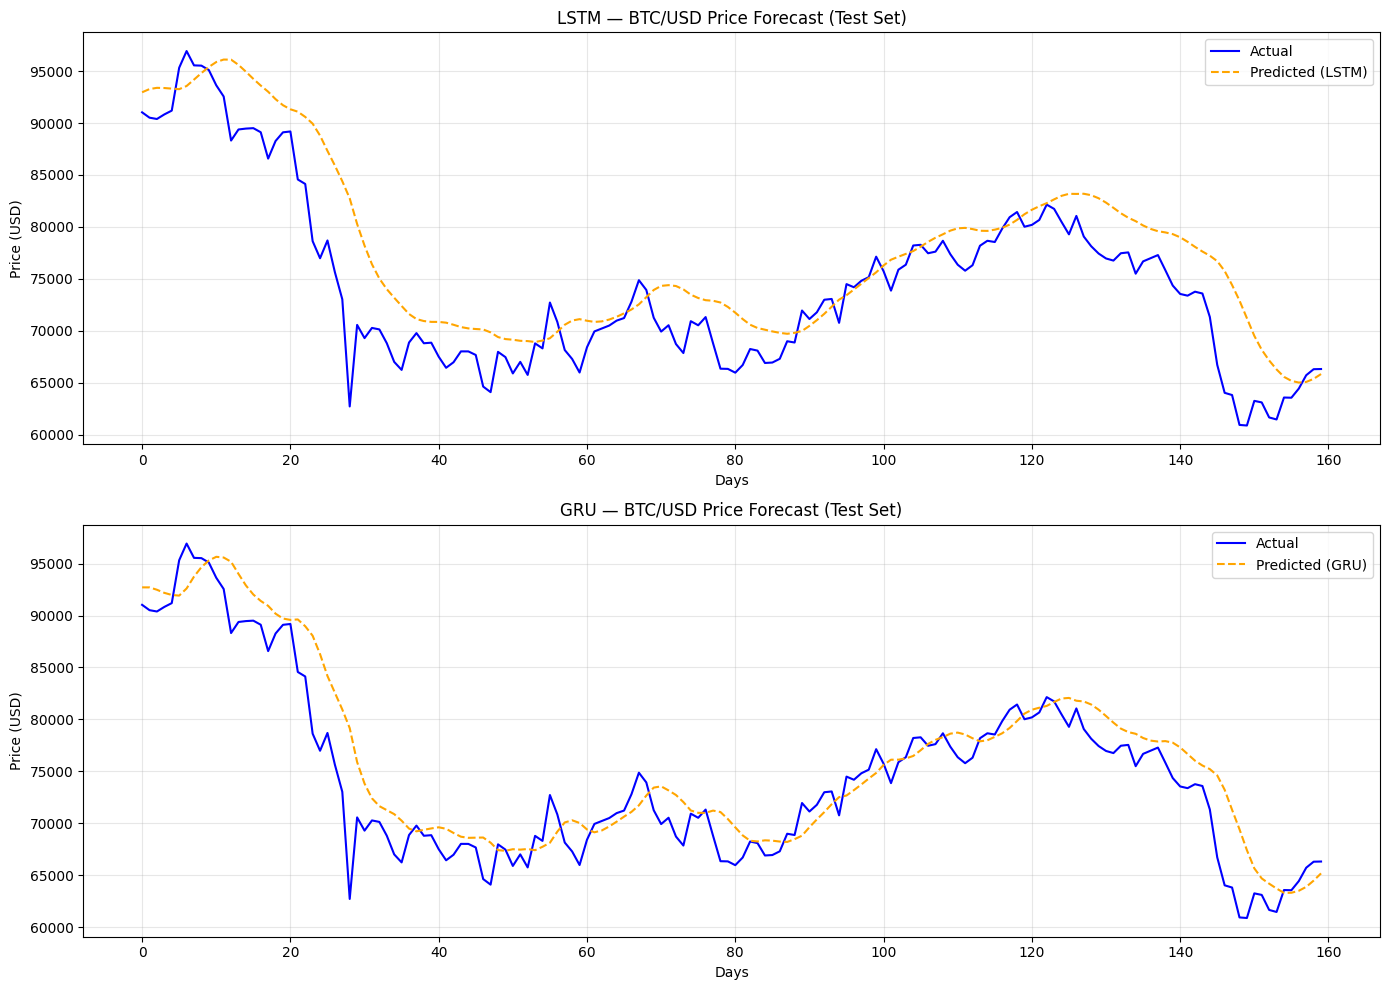

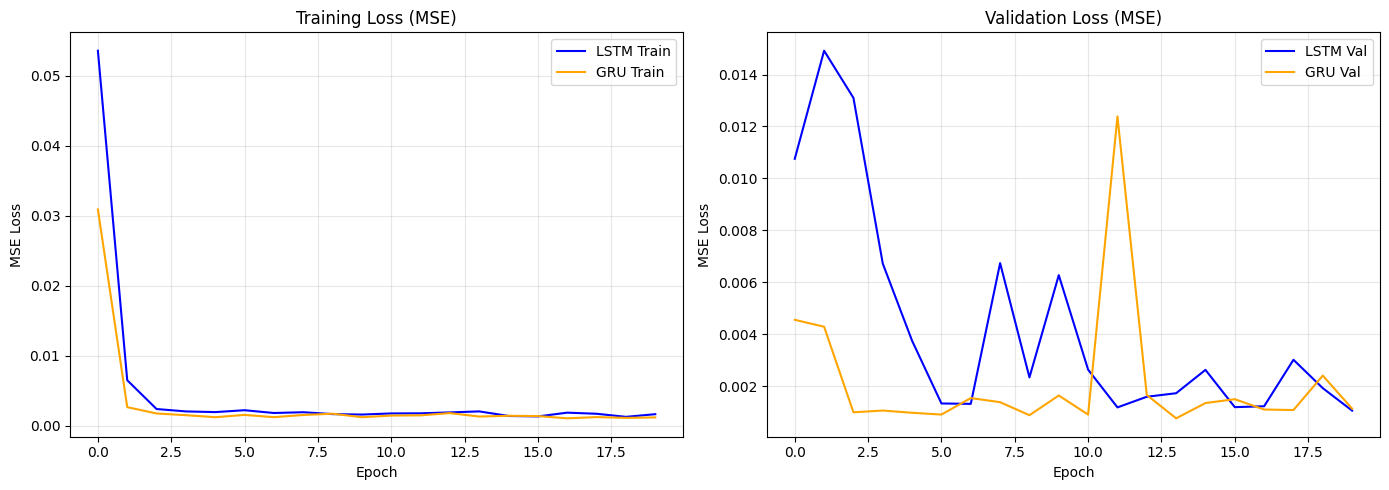


  Model       MAE ($)   RMSE ($)       R²
  LSTM       3,525.81   4,658.18   0.6932
  GRU         2,369.65   3,287.25   0.8472


In [21]:
# Plot actual vs predicted
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, preds, name in zip(axes, [pred_lstm, pred_gru], ['LSTM', 'GRU']):
    ax.plot(true,  label='Actual',    color='blue',   linewidth=1.5)
    ax.plot(preds, label=f'Predicted ({name})', color='orange', linewidth=1.5, linestyle='--')
    ax.set_title(f'{name} — BTC/USD Price Forecast (Test Set)')
    ax.set_ylabel('Price (USD)')
    ax.set_xlabel('Days')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ts_forecast.png', dpi=100, bbox_inches='tight')
plt.show()

# Training loss curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for hist, name, color in [(hist_lstm, 'LSTM', 'blue'), (hist_gru, 'GRU', 'orange')]:
    ax1.plot(hist['train_loss'], label=f'{name} Train', color=color)
    ax2.plot(hist['val_loss'],   label=f'{name} Val',   color=color)
for ax, title in zip([ax1, ax2], ['Training Loss (MSE)', 'Validation Loss (MSE)']):
    ax.set(title=title, xlabel='Epoch', ylabel='MSE Loss')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ts_loss_curves.png', dpi=100, bbox_inches='tight')
plt.show()

# Comparison table
print('\n' + '='*45)
print(f"  {'Model':<8} {'MAE ($)':>10} {'RMSE ($)':>10} {'R²':>8}")
print('='*45)
print(f"  {'LSTM':<8} {mae_l:>10,.2f} {rmse_l:>10,.2f} {r2_l:>8.4f}")
print(f"  {'GRU':<8}  {mae_g:>10,.2f} {rmse_g:>10,.2f} {r2_g:>8.4f}")
print('='*45)

## A6. Optional: Transformer Comparison

In [23]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class TransformerForecaster(nn.Module):
    """
    Transformer encoder for time series forecasting.
    Input:  (batch, seq_len, 1)
    Output: (batch, 1)
    """
    def __init__(self, input_size=1, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_enc    = PositionalEncoding(d_model, dropout=dropout)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True)
        self.encoder    = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc         = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.pos_enc(self.input_proj(x))  # (B, seq, d_model)
        x = self.encoder(x)
        return self.fc(x[:, -1, :])           # last token


transformer_model = TransformerForecaster().to(device)
print(f'Transformer params: {sum(p.numel() for p in transformer_model.parameters()):,}')

print('\n=== Training Transformer Forecaster ===')
hist_transformer = train_ts_model(
    transformer_model, train_loader_ts, val_loader_ts,
    epochs=20, lr=5e-4, model_name='transformer'
)
_, pred_transformer, mae_t, rmse_t, r2_t = evaluate_ts(
    transformer_model, X_test, y_test, scaler, 'Transformer', 'transformer_best.pt')

print('\n=== Full Comparison ===')
print(f"{'Model':<14} {'MAE':>12} {'RMSE':>12} {'R²':>8}")
print('-'*50)
for name, mae, rmse, r2 in [('LSTM', mae_l, rmse_l, r2_l),
                              ('GRU',  mae_g, rmse_g, r2_g),
                              ('Transformer', mae_t, rmse_t, r2_t)]:
    print(f'{name:<14} ${mae:>10,.2f} ${rmse:>10,.2f} {r2:>8.4f}')

Transformer params: 67,137

=== Training Transformer Forecaster ===
Epoch [  1/20] Train MSE: 0.037100 | Val MSE: 0.015700
Epoch [ 10/20] Train MSE: 0.003237 | Val MSE: 0.001633
Epoch [ 20/20] Train MSE: 0.002005 | Val MSE: 0.000872
Best Val MSE: 0.000872

Transformer — Test Set Metrics:
  MAE:  $4,269.15
  RMSE: $5,237.57
  R²:   0.6121

=== Full Comparison ===
Model                   MAE         RMSE       R²
--------------------------------------------------
LSTM           $  3,525.81 $  4,658.18   0.6932
GRU            $  2,369.65 $  3,287.25   0.8472
Transformer    $  4,269.15 $  5,237.57   0.6121


---
# PART B: Text Generation (Character-Level LSTM)
---

## B1. Load & Preprocess Text Corpus

In [24]:
import urllib.request

# Download a ~1MB Shakespeare corpus
URL = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
text_path = 'shakespeare.txt'

if not os.path.exists(text_path):
    urllib.request.urlretrieve(URL, text_path)
    print('Downloaded Shakespeare corpus.')

with open(text_path, 'r', encoding='utf-8') as f:
    text = f.read()

print(f'Total characters: {len(text):,}')
print(f'Unique characters: {len(set(text))}')
print('\nFirst 300 characters:')
print(text[:300])

Total characters: 1,115,394
Unique characters: 65

First 300 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


In [25]:
# ── Character-level vocabulary ─────────────────────────────
chars   = sorted(set(text))
VOCAB   = len(chars)
char2id = {c: i for i, c in enumerate(chars)}
id2char = {i: c for c, i in char2id.items()}

print(f'Vocabulary size: {VOCAB}')
print(f'Characters: {repr("".join(chars[:50]))}')

# Encode full text to integer IDs
text_ids = np.array([char2id[c] for c in text], dtype=np.int64)
print(f'\nEncoded shape: {text_ids.shape}')

Vocabulary size: 65
Characters: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijk"

Encoded shape: (1115394,)


In [26]:
SEQ_LEN   = 100   # input sequence length
TEXT_BATCH = 128

# Train/val/test split (80/10/10)
n_text  = len(text_ids)
tr_end  = int(n_text * 0.80)
va_end  = int(n_text * 0.90)

class CharDataset(Dataset):
    """Returns overlapping (input_seq, target_seq) pairs."""
    def __init__(self, data, seq_len):
        self.data    = torch.tensor(data, dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        return (self.data[idx : idx + self.seq_len],
                self.data[idx + 1 : idx + self.seq_len + 1])

train_text_ds = CharDataset(text_ids[:tr_end], SEQ_LEN)
val_text_ds   = CharDataset(text_ids[tr_end:va_end], SEQ_LEN)
test_text_ds  = CharDataset(text_ids[va_end:], SEQ_LEN)

train_text_loader = DataLoader(train_text_ds, batch_size=TEXT_BATCH, shuffle=True,  drop_last=True)
val_text_loader   = DataLoader(val_text_ds,   batch_size=TEXT_BATCH, shuffle=False, drop_last=True)

print(f'Train sequences: {len(train_text_ds):,}')
print(f'Val sequences:   {len(val_text_ds):,}')

Train sequences: 892,215
Val sequences:   111,439


## B2. Character LSTM Language Model

In [27]:
class CharLSTM(nn.Module):
    """
    Character-level LSTM language model.

    Forward pass:
      char_ids → Embedding → LSTM layers → Linear → logits

    Input:  (batch, seq_len)  — integer character IDs
    Output: (batch, seq_len, vocab_size)  — logits for next character
    """
    def __init__(self, vocab_size, embed_dim=64, hidden_size=256, num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.embed       = nn.Embedding(vocab_size, embed_dim)
        self.lstm        = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.embed(x)                          # (B, T, embed_dim)
        out, hidden = self.lstm(emb, hidden)         # (B, T, hidden)
        out = self.dropout(out)
        logits = self.fc(out)                        # (B, T, vocab_size)
        return logits, hidden

    def init_hidden(self, batch_size):
        h = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
        c = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
        return (h, c)


char_model = CharLSTM(vocab_size=VOCAB).to(device)
print(f'CharLSTM params: {sum(p.numel() for p in char_model.parameters()):,}')

CharLSTM params: 876,929


## B3. Training with Perplexity Tracking

In [28]:
def train_char_model(model, train_loader, val_loader, epochs=30, lr=3e-3):
    """
    Train character-level LSTM. Tracks loss and perplexity.
    Perplexity = exp(cross_entropy_loss)
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_ppl': [], 'val_ppl': []}
    best_val = float('inf')

    for epoch in range(epochs):
        # Training
        model.train()
        total_loss, total_tokens = 0.0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits, _ = model(X_batch)
            # Reshape: (B*T, vocab) vs (B*T,)
            loss = criterion(logits.reshape(-1, VOCAB), y_batch.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            total_loss   += loss.item() * X_batch.numel()
            total_tokens += X_batch.numel()

        train_loss = total_loss / total_tokens

        # Validation
        model.eval()
        val_loss_sum, val_tokens = 0.0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits, _ = model(X_batch)
                loss = criterion(logits.reshape(-1, VOCAB), y_batch.reshape(-1))
                val_loss_sum += loss.item() * X_batch.numel()
                val_tokens   += X_batch.numel()
        val_loss = val_loss_sum / val_tokens
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_ppl'].append(math.exp(train_loss))
        history['val_ppl'].append(math.exp(val_loss))

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), 'char_lstm_best.pt')

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1:>3}/{epochs}] '
                  f'Train Loss: {train_loss:.4f} PPL: {math.exp(train_loss):.1f} | '
                  f'Val Loss: {val_loss:.4f} PPL: {math.exp(val_loss):.1f}')

    print(f'Best Val Loss: {best_val:.4f} | PPL: {math.exp(best_val):.2f}')
    return history


text_history = train_char_model(char_model, train_text_loader, val_text_loader, epochs=5, lr=3e-3)

Epoch [  1/5] Train Loss: 1.3196 PPL: 3.7 | Val Loss: 1.4842 PPL: 4.4
Epoch [  5/5] Train Loss: 1.0634 PPL: 2.9 | Val Loss: 1.6039 PPL: 5.0
Best Val Loss: 1.4842 | PPL: 4.41


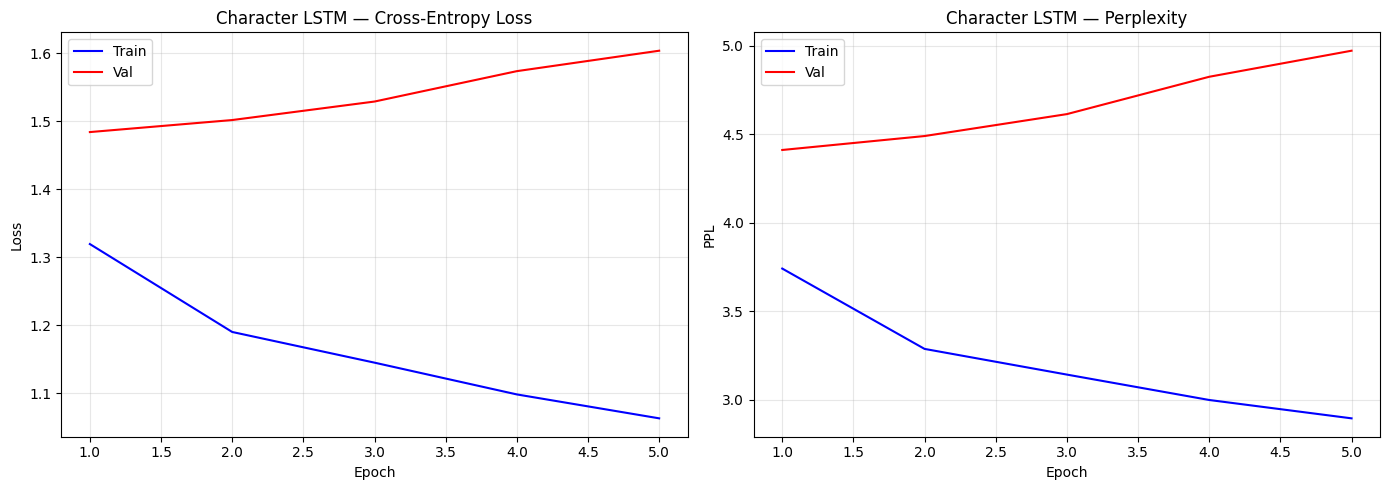

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(text_history['train_loss']) + 1)

ax1.plot(epochs_range, text_history['train_loss'], 'b-', label='Train')
ax1.plot(epochs_range, text_history['val_loss'],   'r-', label='Val')
ax1.set(title='Character LSTM — Cross-Entropy Loss', xlabel='Epoch', ylabel='Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_range, text_history['train_ppl'], 'b-', label='Train')
ax2.plot(epochs_range, text_history['val_ppl'],   'r-', label='Val')
ax2.set(title='Character LSTM — Perplexity', xlabel='Epoch', ylabel='PPL')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('text_training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

## B4. Text Generation with Temperature Sampling

In [30]:
@torch.no_grad()
def generate_text(model, seed_text, char2id, id2char, n_chars=500,
                  temperature=1.0, top_k=0):
    """
    Generate text autoregressively from a seed string.

    temperature: controls randomness
      < 1.0 → more deterministic (conservative)
      > 1.0 → more creative (risky)
    top_k: if > 0, sample only from top-k most likely characters
    """
    model.eval()
    model.load_state_dict(torch.load('char_lstm_best.pt', map_location=device))

    # Warm up hidden state with seed
    input_ids = [char2id.get(c, 0) for c in seed_text]
    input_t   = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)
    logits, hidden = model(input_t)

    generated = list(seed_text)

    # Sample next character iteratively
    next_id = input_ids[-1]
    for _ in range(n_chars):
        x  = torch.tensor([[next_id]], dtype=torch.long).to(device)
        logits, hidden = model(x, hidden)
        logits_last = logits[0, -1] / temperature  # shape: (vocab,)

        if top_k > 0:
            # Zero out all logits except top-k
            vals, _ = torch.topk(logits_last, top_k)
            threshold = vals[-1]
            logits_last[logits_last < threshold] = float('-inf')

        probs   = torch.softmax(logits_last, dim=-1)
        next_id = torch.multinomial(probs, 1).item()
        generated.append(id2char[next_id])

    return ''.join(generated)


seed = 'ROMEO:\nBut soft, what light'

print('='*60)
for temp in [0.5, 0.8, 1.0, 1.2]:
    print(f'\n--- Temperature = {temp} ---')
    generated = generate_text(char_model, seed, char2id, id2char,
                              n_chars=300, temperature=temp, top_k=5)
    print(generated)
    print()


--- Temperature = 0.5 ---
ROMEO:
But soft, what lighty singular that I will
not be so for a bark and many an oath is spent
To make her speak to a day in him.

BRAKENBURY:
I was a sail, that thou art as much between
The while, and thou the while to be the world.

LADY ANNE:
Here comes the prince that hath a shame that have
The traitor to the cause of h


--- Temperature = 0.8 ---
ROMEO:
But soft, what lighty state?

First Lord:
I will be thou they are born to me that they are spent
To see and bury them, and shall be so.

CLARENCE:
We will so much o'er a man of sight.

DUKE OF YORK:
I shall, and therefore would be a prince.

LADY ANNE:
The souls and blast of the wind of that would have
Which he would t


--- Temperature = 1.0 ---
ROMEO:
But soft, what lighting seems do now?

CORIOLANUS:
It is a black feast and more throng.

AUTOLYCUS:
Has I that sent thee to a least?

LEONTES:
They were a morning when he is not, as
thy besedich to his still, and the husband
Shall set upon the stroke, ti

## Summary & Analysis

### LSTM vs GRU

| Feature | LSTM | GRU |
|---|---|---|
| Gates | 3: input, forget, output | 2: reset, update |
| Cell state | Separate cell state + hidden state | Only hidden state |
| Parameters | More | ~33% fewer |
| Training speed | Slower | Faster |
| Performance | Slightly better on long sequences | Comparable on most tasks |
| When to use | Very long sequences, complex dependencies | Faster training needed, similar accuracy |

### When RNNs outperform Transformers
- **Small datasets:** Transformers need more data; RNNs generalize better with limited samples.
- **Memory-constrained environments:** RNNs have O(1) memory for inference (just the hidden state).
- **Online/streaming data:** RNNs process sequences incrementally.

### When Transformers win
- **Parallelization:** The entire sequence processed simultaneously during training.
- **Long-range dependencies:** Attention has O(1) path length between any two positions; RNNs have O(n).
- **Large datasets:** Scale better with more data and compute.

### Temperature in Text Generation
- **Low temp (0.5):** Conservative, repetitive but coherent text.
- **Medium temp (0.8–1.0):** Good balance between creativity and coherence.
- **High temp (1.2+):** Creative and surprising, but often grammatically incorrect.